In [2]:
import pandas as pd

df = pd.read_csv("ecommerce_customer_data_large.csv")

print("Dataset Loaded Successfully")
print(df.shape)

df.head()

Dataset Loaded Successfully
(250000, 13)


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [4]:
print(df.columns.tolist())

['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn']


In [7]:
print(df.columns.tolist())

['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn']


In [9]:


df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 24.8 MB


In [ ]:


df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47382
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [13]:
# Check Duplicate Records

df.duplicated().sum()

np.int64(0)

In [15]:
# Remove Duplicates

df = df.drop_duplicates()

# Fill Missing Numeric Values

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill Missing Categorical Values

categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Data Cleaning Completed")

Data Cleaning Completed


C:\Users\hp\AppData\Local\Temp\ipykernel_18460\189873639.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [17]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

Duplicate Rows:
0


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

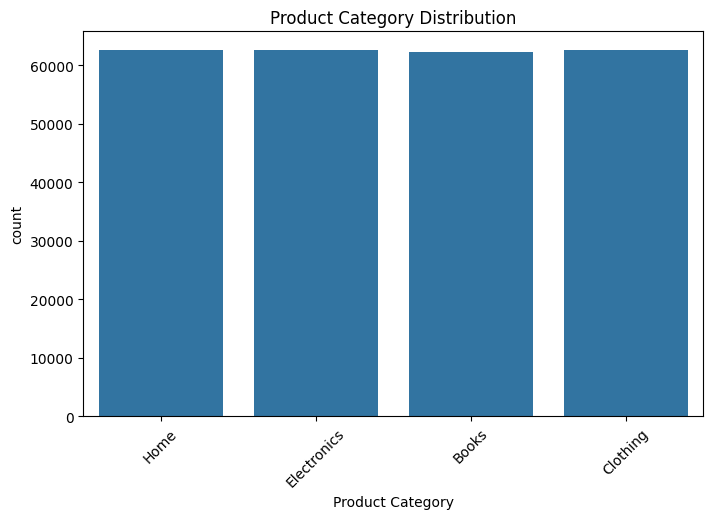

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Product Category')

plt.title("Product Category Distribution")
plt.xticks(rotation=45)

plt.show()

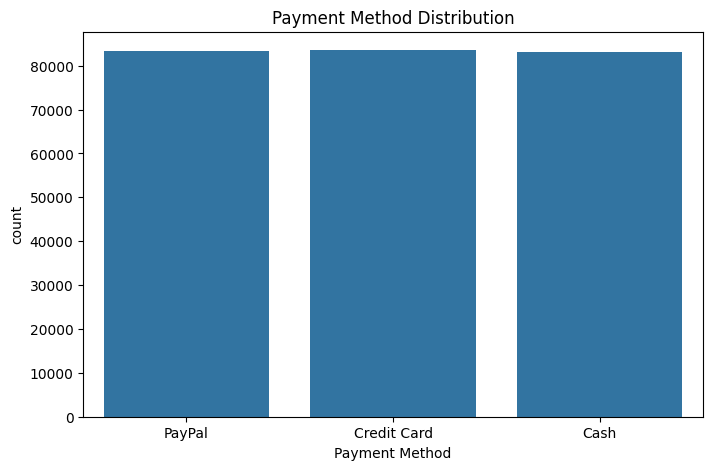

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Payment Method')

plt.title("Payment Method Distribution")

plt.show()

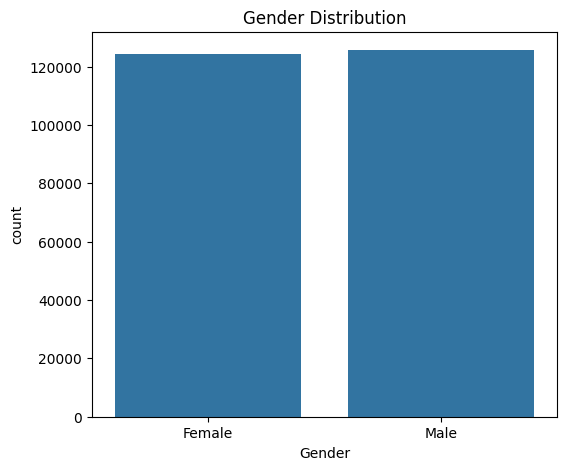

In [25]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Gender')

plt.title("Gender Distribution")

plt.show()

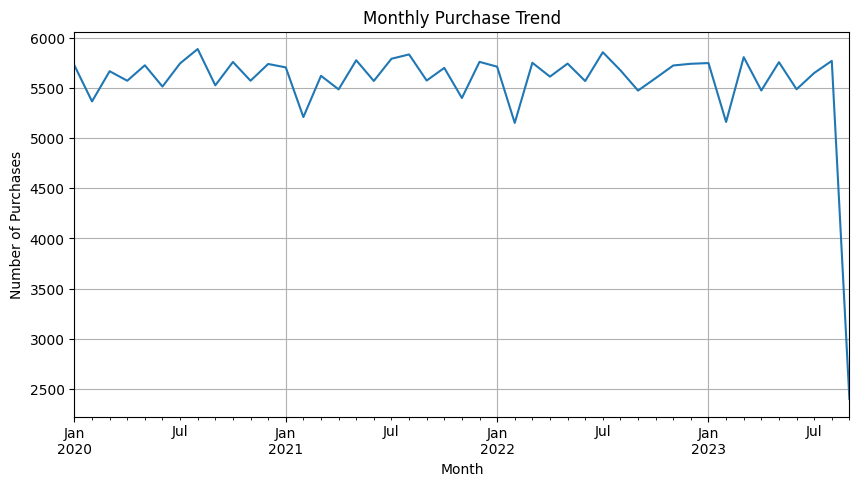

In [28]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

monthly_sales = df.groupby(
    df['Purchase Date'].dt.to_period('M')
).size()

monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Purchase Trend")

plt.xlabel("Month")
plt.ylabel("Number of Purchases")

plt.grid()

plt.show()

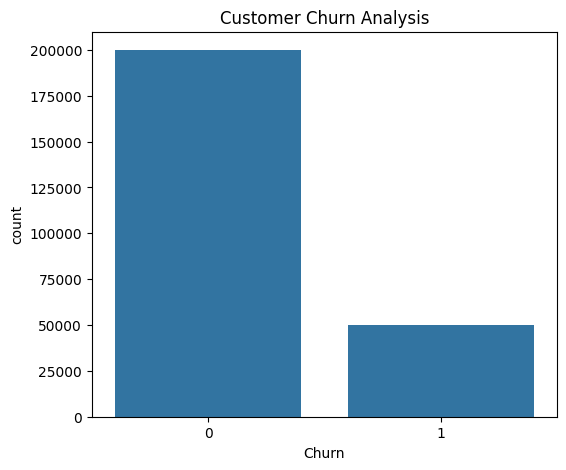

In [30]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='Churn')

plt.title("Customer Churn Analysis")

plt.show()

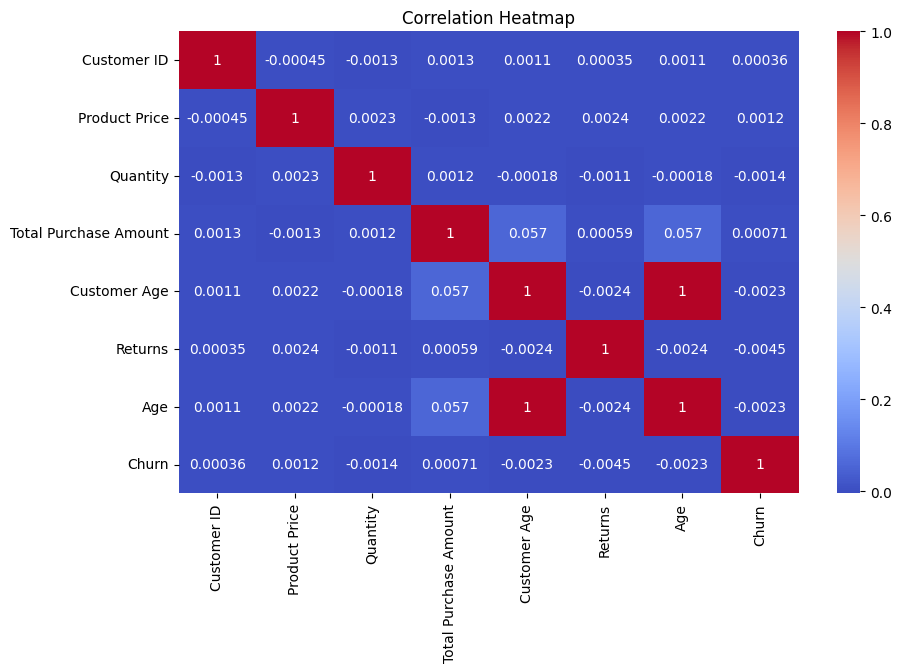

In [32]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [34]:
print("CUSTOMER BEHAVIOR ANALYSIS INSIGHTS")

print("\n1. Product categories reveal customer preferences.")
print("\n2. Payment methods indicate customer transaction choices.")
print("\n3. Monthly purchase trends identify peak sales periods.")
print("\n4. Churn analysis helps understand customer retention.")
print("\n5. Correlation heatmap shows relationships between numerical variables.")
print("\n6. These insights can support marketing and customer retention strategies.")

CUSTOMER BEHAVIOR ANALYSIS INSIGHTS

1. Product categories reveal customer preferences.

2. Payment methods indicate customer transaction choices.

3. Monthly purchase trends identify peak sales periods.

4. Churn analysis helps understand customer retention.

5. Correlation heatmap shows relationships between numerical variables.

6. These insights can support marketing and customer retention strategies.
